# **SED CALIB**

Tests on a sed library with one degree of freedom: alpha (normalisation).

## **0. Initialisation**

### 0.1 Packages

In [55]:
### Libs ###
from imports import *

#custom
from src.download_bt_spectra import download_bt_spectra
import src.data_manipulations as dm; reload(dm)
import src.plot_tools as pt; reload(pt)
import src.photometry_errors as pe; reload(pe)
from src.format_to_dat import format_to_lephareinput 

#lephare
import lephare as lp
config = lp.default_stargal_config.copy()

base_dir = os.path.abspath(os.path.join(os.getcwd()))
sys.path.append(base_dir)

%matplotlib inline

### 0.2 Important inputs

In [56]:
n_sources = 10000 # Number of sources per template to sample
max_row_lephare = 100000 # Number of rows to loop on with zphota
work_with_absmags = True # If true, mag_obs --> mag_obs - deltam
return_dm = True # return dm in mock table
if work_with_absmags == True: #must be true in this case
    return_dm = True


#physical quantities of seds to download.
#WARNING: The number of seds downloaded is equal to len(teff_values) x len(logg_values) x (metallicity_values), 
#so it could need a lot of space!
teff_values = 10200 #values of simulated sed surface temperature, or list of 
logg_values = 3 #values of simulated sed surface gravity, or list of 
metallicity_values = 0 #values of simulated sed metallicity, or list of 

#if true, delete temporary files
clean_cache = True #lephare sedlib and maglib cache
clean_seds = False #local directory seds

### 0.3 Download spectra

Use ``download_bt_spectra.py``

In [57]:
#--- Downloading parameters--- 
#model
MODEL = "bt-nextgen-agss2009"
BASE_URL = f"https://svo2.cab.inta-csic.es/theory/newov2/ssap.php?model={MODEL}" #website to download from

#dl directory
sed_name = f"Teff{teff_values}logg{logg_values}feh{metallicity_values}" #WARNING: name after fixed parameter
local_dir = f'data/tests/bt_spectra_{sed_name}'#directory to download in
OUTPUT_DIR = os.path.abspath(os.path.join(base_dir, local_dir))

#Control wavelength range and resolution
LMIN = 1145.0   # Å, set to None to keep full range
LMAX = 25005.0  # Å
DL   = 5.0      # Å, set to None to keep original sampling
wl_norm = 10000 # Å. Lot of space earned
make_sed_list = True # create sed list in the same folder
overwrite_seds = False # if true, overwrite identically named seds
list_name = f"bt_star_sed_{sed_name}"

#--- Download ---
download_bt_spectra(MODEL=MODEL, BASE_URL=BASE_URL, OUTPUT_DIR=OUTPUT_DIR,
    teff_values=teff_values, logg_values=logg_values, metallicity_values=metallicity_values,
    LMIN=LMIN, LMAX=LMAX, DL=DL, wl_norm=wl_norm,
    make_sed_list=make_sed_list, overwrite_seds=overwrite_seds, list_name=list_name,)

13627 <TR> lines found in VOTABLE.
1 spectra found matching with the chosen grid.
T_eff=10200, logg=3.0, Fe/H=0.0 already exists. Pass.
All available spectrum have been downloaded and formated.


## **1. Run first LePHARE steps**

In [58]:
filt_fname = "photozdc1"
sedlib_prefix = "BT_SEDs_"
maglib_prefix = "BT_LSST_"

### 1.0 Filter to lib (optional)

In [59]:
# # If you want to add more or less filters

# #--- With LSST filters ---
# filter_path = f"{base_dir}/data/filt" 

# filter_rep = lp.keyword("FILTER_REP", filter_path)
# filter_list = lp.keyword("FILTER_LIST",
# "BuzzardLSSTu.res,BuzzardLSSTg.res,BuzzardLSSTr.res,\
#      BuzzardLSSTi.res,BuzzardLSSTz.res,BuzzardLSSTy4.res,EUC_J.ecf")

# filterLib = lp.Filter(config_keymap={"FILTER_REP":filter_rep,
#                                    "FILTER_LIST":filter_list,
#                                    "TRANS_TYPE":lp.keyword("TRANS_TYPE", "0"),
#                                    "FILTER_CALIB":lp.keyword("FILTER_CALIB", "0"), #"0,0,0,0,0,0"
#                                    "FILTER_FILE":lp.keyword("FILTER_FILE", filt_fname)})


# filterLib.run()

### 1.1 Sed to Lib

In [60]:
#--- With BT ---
SED_list_path = f"{base_dir}/{local_dir}/{list_name}.list"
sedLib = lp.Sedtolib(config_keymap={
    "STAR_SED": lp.keyword("STAR_SED", SED_list_path),
    "STAR_FSCALE": lp.keyword("STAR_FSCALE", "3.432E-09"),
    "STAR_LIB": lp.keyword("STAR_LIB", f'{sedlib_prefix}{sed_name}')},)
    
sedLib.run(typ="S")

#######################################
# It s translating SEDs to binary library #
# with the following options :           
# Config file     : 
# Library type     : STAR
# STAR_SED    :/home/hallouin/Documents/t_hall/lephare-u-Tototime-sedlib-calibration/calibration/data/tests/bt_spectra_Teff10200logg3feh0/bt_star_sed_Teff10200logg3feh0.list
# STAR_LIB    :BT_SEDs_Teff10200logg3feh0
# STAR_LIB doc:/home/hallouin/.cache/lephare/work/lib_bin/BT_SEDs_Teff10200logg3feh0.doc
# STAR_FSCALE :0.0000
#######################################
Number of SED in the list 1


### 1.2 MagGal

In [61]:
maglib = lp.MagGal(config_keymap=lp.all_types_to_keymap(config))

star_lib_in = f"{sedlib_prefix}{sed_name}"
star_lib_out = f"{maglib_prefix}{sed_name}"
maglib.run(typ="S",
    star_lib_in=star_lib_in,
    star_lib_out=star_lib_out,
    filter_file=filt_fname,
    magtype="AB",
    mod_extinc="0",
    extinc_law="calzetti.dat",
    em_dispersion="0",
    lib_ascii="YES",
    z_step="0.0,0,0")

#######################################
# It s computing the SYNTHETIC MAGNITUDES #
# For Gal/QSO libraries with these OPTIONS #
# with the following options :           
# Config file     : 
# Filter file     : photozdc1
# Magnitude type     : AB
# COSMOLOGY   :70.0000,0.3000,0.7000
# STAR_LIB_IN    :/home/hallouin/.cache/lephare/work/lib_bin/BT_SEDs_Teff10200logg3feh0(.doc & .bin)
# STAR_LIB_OUT   :/home/hallouin/.cache/lephare/work/lib_mag/BT_LSST_Teff10200logg3feh0(.doc & .bin)
# LIB_ASCII   YES
# CREATION_DATE Tue Mar 24 18:10:28 2026
#############################################


## **2. Make mock catalog from mag lib**

### 2.1 Load magbin into pandas and sed physical data

In [62]:
#--- copy-paste maglib from the lepahre cache folder ---
from pathlib import Path
import shutil
cache_dir = Path.home() / f".cache/lephare/work/lib_mag" 
paste_path = f"{base_dir}/{local_dir}/"
shutil.copy(f"{cache_dir}/{star_lib_out}.dat", paste_path)

'/home/hallouin/Documents/t_hall/lephare-u-Tototime-sedlib-calibration/calibration/data/tests/bt_spectra_Teff10200logg3feh0/BT_LSST_Teff10200logg3feh0.dat'

In [63]:
#--- Convert to pandas ---
maglib = dm.maglib_to_pandas(f"{base_dir}/{local_dir}/{star_lib_out}.dat")

In [64]:
#--- Generate sed grid with associated physical values from names ---
class SED_GRID:
    '''
    For a SED set dependent on physical parameters, construct a coherent grid.
    '''
    def __init__(self, list_path):
        """Load SED list."""
        sed_list = []
        with open(list_path, 'r') as file:
            for line in file:
                line = line.strip()
                if line.startswith('#') or not line:
                    continue
                filepath = line.split()[0]
                sp_type = filepath.split('/')[-1].replace('.sed', "")
                sed_list.append(sp_type)
        self.sed_list = sed_list
        self.sed_grid = None

    def build(self):
        """Build the sed grid [Id, Teff, logg, FeH] from filenames."""
        pattern = r"Teff([-\d\.]+)_logg([-\d\.]+)_FeH([-\d\.]+)"
        sed_grid = []
        for Id, s in enumerate(self.sed_list):
            match = re.search(pattern, s)
            if match:
                Teff, logg, FeH = match.groups()
                Teff, logg, FeH = float(Teff), float(logg), float(FeH)
                sed_grid.append([Id, Teff, logg, FeH])
        self.sed_grid = np.array(sed_grid)
        return self.sed_grid

sed_grid_path = f'{base_dir}/{local_dir}/{list_name}.list'
sed_grid_init = SED_GRID(sed_grid_path)
sed_grid = sed_grid_init.build()
sed_grid[:,0] = sed_grid[:,0] + 1
sed_grid = pd.DataFrame(sed_grid, columns=["model", "teff", "logg", "feh"])

In [65]:
#--- Merge in the one table from which we generate mock mags ---
maglib = dm.join_tables(maglib, (sed_grid, "model", "model"))
maglib[:3]

,model,N_filt,magnitude_u,magnitude_g,magnitude_r,magnitude_i,magnitude_z,magnitude_y,teff,logg,feh
0,1.0,6.0,-1.63324,-2.02598,-1.73881,-1.48472,-1.33342,-1.282,10200.0,3.0,0.0


### 2.2 Generate sources

In [66]:
#--- Class to sample sources and apply errors ---
class MockPhotometry:        
    @staticmethod
    def generate_sources_from_magabs(mags, ref_index, mag_min, mag_max, N, method="uniform", return_dm=False):
        """
        Generates N sources from a SED in magnitudes, with the reference band
        uniformly distributed between mag_min and mag_max. The other bands are
        shifted to preserve colors.
        """
        mags = np.array(mags)
        Nband = len(mags)
        if method == 'uniform':
            ref_mags = np.random.uniform(low=mag_min, high=mag_max, size=N)
            delta_M = ref_mags - mags[ref_index]
            sources = mags[None, :] + delta_M[:, None]
        else:
            raise NotImplementedError(f"Method '{method}' not implemented yet")
        if return_dm == True:
            return sources, delta_M[:, None]
        else:
            return sources

    @staticmethod
    def generate_sources_from_table(table, mag_cols, ref_index, mag_min, mag_max, N_per_star, 
                                    method="uniform", return_full_table=False, return_dm=False):
        """
        Generates mock sources for each source from a Pandas table.
        """
        mock_list = []

        mock_list = []

        for _, row in table.iterrows():
            mags = row[mag_cols].values
            mock_mags = MockPhotometry.generate_sources_from_magabs(mags, ref_index, mag_min, mag_max, N_per_star, method, return_dm)

            if return_dm == True:
                sources = mock_mags[0]
                sources_dm = mock_mags[1]
                df_sources = pd.DataFrame(np.concat((sources,sources_dm), axis=1), columns=np.concat((mag_cols,["mag_dm"])))
            else:
                sources = mock_mags
                df_sources = pd.DataFrame(sources, columns=mag_cols)

            if return_full_table:
                # dupliquer les autres colonnes
                other_cols = row.drop(labels=mag_cols)
                df_other = pd.DataFrame([other_cols.values]*N_per_star, columns=other_cols.index)

                df_sources = pd.concat([df_other.reset_index(drop=True),
                                        df_sources.reset_index(drop=True)],
                                        axis=1)

            mock_list.append(df_sources)

        df_mock = pd.concat(mock_list, ignore_index=True)

        return df_mock
    
    @staticmethod
    def generate_errors(table, mag_columns, models=None, model_names=None, suffix="_err_sim", error_cut=None,
                random_state=None, format="MMEE", add_errors=True, keep_true_mags=True, default_error_value=None):
        """ 
        Generate photometric errors using PhotometricErrorModel and optionally
        add Gaussian noise to magnitudes.
        """

        if default_error_value is not None:
            table_with_errs = table.copy()
            for col in mag_columns:
                table_with_errs[col + suffix] = np.full(len(table_with_errs), default_error_value)
                
            if add_errors:
                #sample noisy cols
                rng = np.random.default_rng(random_state)
                mags = table_with_errs[mag_columns].to_numpy(dtype=float)
                err_cols = [c + suffix for c in mag_columns]
                sigmas = table_with_errs[err_cols].to_numpy(dtype=float)
                noise = rng.normal(loc=0.0, scale=sigmas)
                mags_obs = mags + noise
                #add to table
                table_with_errs[mag_columns] = mags_obs
                table_with_errs[err_cols] = sigmas

            if keep_true_mags:
                true_cols = [c + "_true" for c in mag_columns]
                table_with_errs[true_cols] = mags

            return table_with_errs

        # Generate errors
        table_with_errs = pe.PhotometricErrorModel().sample_errors_on_catalog(
            table, mag_columns=mag_columns, models=models, model_names=model_names, format=format)

        if not add_errors:
            return table_with_errs

        rng = np.random.default_rng(random_state)

        # Numpy vectorisation
        mags = table_with_errs[mag_columns].to_numpy(dtype=float)
        err_cols = [c + suffix for c in mag_columns]
        sigmas = table_with_errs[err_cols].to_numpy(dtype=float)
        # Gaussian noise
        noise = rng.normal(loc=0.0, scale=sigmas)

        mags_obs = mags + noise

        if error_cut is not None:
            mask_low_snr = error_cut < sigmas
            mags_obs[mask_low_snr] = np.nan
            sigmas[mask_low_snr] = np.nan

        if keep_true_mags:
            true_cols = [c + "_true" for c in mag_columns]
            table_with_errs[true_cols] = mags

        table_with_errs[mag_columns] = mags_obs
        table_with_errs[err_cols] = sigmas

        return table_with_errs

In [67]:
mock_mags = MockPhotometry.generate_sources_from_table(table=maglib, #panda table
    mag_cols=['magnitude_u','magnitude_g','magnitude_r','magnitude_i','magnitude_z','magnitude_y'], #mag cols
    ref_index=2, #mag col ref
    mag_min=17.5, #minimum mag col ref
    mag_max=26.5, #maximum mag col ref
    N_per_star=n_sources, #n source per row
    method='uniform', #sampling method
    return_full_table=True,
    return_dm=return_dm)

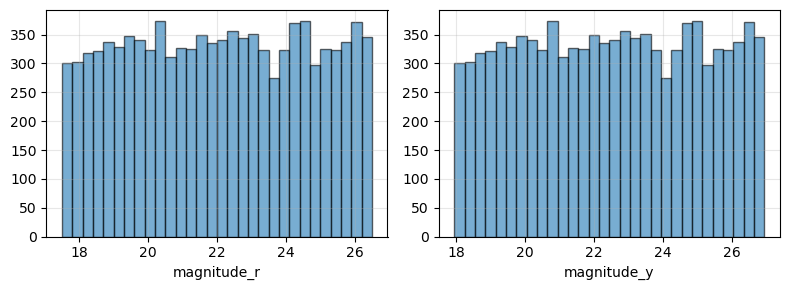

In [68]:
pt.plot_histograms(mock_mags, ["magnitude_r", "magnitude_y"], alpha=0.6, edgecolor="k")

### 2.3 Generate errors and observed mags

Here we generate errors from a gamma error model function of magnitude, made from DP1 error distribution.

Note: the model is quite limited in high/low luminosity due ot lack of sources in the original file.

In [69]:
dp1_ECDFS = pd.read_csv(f"{base_dir}/data/catalogs/DP1_ECDFS_photometry.csv")
dp1_ECDFS = dp1_ECDFS[(dp1_ECDFS["u_cModelMag"]<26.5) & (dp1_ECDFS["g_cModelMag"]<26.5) & (dp1_ECDFS["r_cModelMag"]<26.5) 
                        & (dp1_ECDFS["i_cModelMag"]<26.5) & (dp1_ECDFS["z_cModelMag"]<26.5) & (dp1_ECDFS["y_cModelMag"]<26.5)]

Make error model

In [70]:
pem_dp1_ECDFS = pe.PhotometricErrorModel()

dp1_ECDFS_models = pem_dp1_ECDFS.model_collection(
    x_lists=dp1_ECDFS[["u_cModelMag","g_cModelMag","r_cModelMag","i_cModelMag","z_cModelMag","y_cModelMag"]], #mag list or panda.series
    sigma_lists=dp1_ECDFS[["u_cModelMagErr","g_cModelMagErr","r_cModelMagErr","i_cModelMagErr","z_cModelMagErr","y_cModelMagErr"]], #mag err list or panda.series
    model_names=["u", "g", "r", "i", "z", "y"], #model name list
    sharpness_factor=1.05, #lower queue length of the gamma distribution
    delta_mag=0.005, #bin length in magnitude
    min_per_bin=None, #minimum per bin in mag, to avoid poorly populated bins
    )

Apply

In [71]:
#--- Generate errors ---
mock_cat = MockPhotometry.generate_errors(mock_mags, 
    mag_columns = ['magnitude_u','magnitude_g','magnitude_r','magnitude_i','magnitude_z','magnitude_y'],
    models = dp1_ECDFS_models, #model dict
    model_names = ["u", "g", "r", "i", "z", "y"], #model name to use for each column
    format="MEME", #output column order
    error_cut=5,
    default_error_value=None, #if you want same error for each source
    add_errors=True, #sample observed mags
    )


#--- Optional: Revert to absolute magnitudes ---
if work_with_absmags==True:
    mag_cols = [f"magnitude_{f}" for f in 'ugrizy']
    mag_true_cols = [f"magnitude_{f}_true" for f in 'ugrizy']
    mock_cat[mag_cols] = mock_cat[mag_cols].subtract(mock_cat['mag_dm'], axis=0)
    mock_cat[mag_true_cols] = mock_cat[mag_true_cols].subtract(mock_cat['mag_dm'], axis=0)

mock_cat[:3]

,model,N_filt,teff,logg,feh,magnitude_u,magnitude_u_err_sim,magnitude_g,magnitude_g_err_sim,magnitude_r,...,magnitude_z_err_sim,magnitude_y,magnitude_y_err_sim,mag_dm,magnitude_u_true,magnitude_g_true,magnitude_r_true,magnitude_i_true,magnitude_z_true,magnitude_y_true
0,1.0,6.0,10200.0,3.0,0.0,-1.736749,0.058595,-2.032100,0.011404,-1.721620,...,0.061693,-1.273370,0.147941,24.315002,-1.63324,-2.02598,-1.73881,-1.48472,-1.33342,-1.282
1,1.0,6.0,10200.0,3.0,0.0,-1.636095,0.003532,-2.026026,0.000110,-1.741540,...,0.001338,-1.282986,0.006453,19.292146,-1.63324,-2.02598,-1.73881,-1.48472,-1.33342,-1.282
2,1.0,6.0,10200.0,3.0,0.0,-1.639232,0.017232,-2.025106,0.001248,-1.740694,...,0.016144,-1.239731,0.126131,23.268909,-1.63324,-2.02598,-1.73881,-1.48472,-1.33342,-1.282


In [72]:
#--- Save mock catalog to csv ---
mock_cat.to_csv(f"{base_dir}/{local_dir}/{sed_name}_mock.csv", index=False)

## 3. **zphota**

### 3.1 Convert mock to lephare input

In [73]:
#--- Run if no Ids in your table ---
def add_ids(df, base_id):
    n = len(df)
    width = len(str(n-1))
    df.insert(0, "mock_id", 0)
    df["mock_id"] = str(base_id) + pd.Series(range(n)).astype(str).str.zfill(width)
    
    return df

cat_path = f"{base_dir}/{local_dir}/{sed_name}_mock.csv"
temp = pd.read_csv(cat_path)
temp = add_ids(temp, 123456)
temp.to_csv(cat_path, index=False)

In [74]:
#--- Transfrom csv formated catalog to .dat, valid for lephare ---
csv_in = f"{base_dir}/{local_dir}/{sed_name}_mock.csv"
dat_out = f"{base_dir}/{local_dir}/{sed_name}_mock.dat"

#--- csv cols to use. To be set in right order ---
input_columns = ['mock_id', 
    'magnitude_u', 'magnitude_g', 'magnitude_r', 'magnitude_i', 'magnitude_z', 'magnitude_y',
    'magnitude_u_err_sim', 'magnitude_g_err_sim', 'magnitude_r_err_sim', 'magnitude_i_err_sim', 'magnitude_z_err_sim', 'magnitude_y_err_sim']

format_to_lephareinput(CAT_IN=csv_in,
    CAT_OUT=dat_out,
    input_columns=input_columns,
    n_filters=6,
    CAT_TYPE='long', #short = ident + mags +errmags, long += context + zspec
    simple_convert=False,
    apply_context = 'yes', #compute lephare context from non-valid columns
    facticious_specz = 0., #add/replace same specz value for all source
    shuffle=False,
    max_rows=None,
    error_value_state='default' #If default, nan --> 99
    )

[INFO] Added missing 'context' column automatically.
[INFO] Replacing 1336 missing values with 99.0
[INFO] Added constant spec-z column with value 0.0
[OK] Catalog saved → /home/hallouin/Documents/t_hall/lephare-u-Tototime-sedlib-calibration/calibration/data/tests/bt_spectra_Teff10200logg3feh0/Teff10200logg3feh0_mock.dat


### 3.2 Prepare

In [75]:
config.update({
        "ZPHOTLIB": f"{maglib_prefix}{sed_name}",
        "SPEC_OUT": "NO",
        "CAT_IN": dat_out,
        "INP_TYPE": "M",
        "CAT_TYPE": "LONG",
        "CAT_MAG": "AB",
        "PARA_OUT": f"{base_dir}/stargal_output.para",
        "CAT_OUT": f"{base_dir}/{local_dir}/{sed_name}_mock.out",
        "AUTO_ADAPT": "NO",
        "PDZ_TYPE": "MIN_ZG",
        "CAT_FMT": "MMEE",
        "ERR_SCALE": 0,
        "SPEC_OUT": "NO",
        "CHI2_OUT": "NO",
        "RM_DISCREPENT": 1e9,
    })

zphota = lp.PhotoZ(lp.all_types_to_keymap(config))

####################################### 
# PHOTOMETRIC REDSHIFT with OPTIONS   # 
# Config file            : 
# CAT_IN                 : /home/hallouin/Documents/t_hall/lephare-u-Tototime-sedlib-calibration/calibration/data/tests/bt_spectra_Teff10200logg3feh0/Teff10200logg3feh0_mock.dat
# CAT_OUT                : /home/hallouin/Documents/t_hall/lephare-u-Tototime-sedlib-calibration/calibration/data/tests/bt_spectra_Teff10200logg3feh0/Teff10200logg3feh0_mock.out
# CAT_LINES              : 0 1000000000
# PARA_OUT               : /home/hallouin/Documents/t_hall/lephare-u-Tototime-sedlib-calibration/calibration/stargal_output.para
# INP_TYPE               : M
# CAT_FMT[0:MEME 1:MMEE] : 1
# CAT_MAG                : AB
# ZPHOTLIB               : BT_LSST_Teff10200logg3feh0 
# FIR_LIB                : 
# FIR_LMIN               : 7.000000
# FIR_CONT               : -1.000000
# FIR_SCALE              : -1.000000
# FIR_FREESCALE          : YES
# FIR_SUBSTELLAR         : NO
# ERR_SCALE            

### 3.3 RUN

In [76]:
#--- Prepare ---
cat = np.loadtxt(dat_out)
id = cat[:, 0]
mag = cat[:, 1:7]
emag = cat[:, 7:13]
context = cat[:, 13]
zspec = cat[:, 14]
srclist = []
n = np.min((len(cat), max_row_lephare))
for i in range(n):
    oneObj = lp.onesource(i, zphota.gridz)
    oneObj.readsource(str(id[i]), mag[i, :], emag[i, :], int(context[i]), zspec[i], " ")
    zphota.prep_data(oneObj)
    srclist.append(oneObj)

#--- Run ---
zphota.run_photoz(srclist[:n], [0,0,0,0,0,0])
final = zphota.build_output_tables(srclist[:n], filename=f"{base_dir}/{local_dir}/{sed_name}_mock.fits")

final[:3]

IDENT,Z_BEST,Z_MED,Z_MODE,CHI_BEST,MOD_BEST,SCALE_BEST,NBAND_USED,Z_SEC,CHI_SEC,MOD_STAR,CHI_STAR,SCALE_STAR,MAG_OBS(),ERR_MAG_OBS(),ZSPEC,PDF_MIN_ZG()
str12,float64,float64,float64,float64,int64,float64,int64,float64,float64,int64,float64,float64,float64[6],float64[6],float64,float64[2]
1234560000.0,-99.9,-99.9,0.0,1000000000.0,-99,-99.0,6,-99.9,-99.0,1,12.962349613113128,0.9881711300213122,-1.7367499999999918 .. -1.2733699999999963,0.05860000000000001 .. 0.14794,0.0,0.0 .. 0.0
1234560001.0,-99.9,-99.9,0.0,1000000000.0,-99,-99.0,6,-99.9,-99.0,1,5.999924520282962,1.00004308611038,-1.636099999999992 .. -1.2829899999999999,0.00353 .. 0.006450000000000002,0.0,0.0 .. 0.0
1234560002.0,-99.9,-99.9,0.0,1000000000.0,-99,-20.26104417670683,6,-99.9,-99.0,1,11.007717870458144,0.9998259690625834,-1.6392299999999853 .. -1.2397299999999927,0.01723 .. 0.12613,0.0,0.0 .. 0.0


Cleaning files

In [77]:
if clean_seds == True:
    sed_grid_path = f'{base_dir}/{local_dir}/{list_name}.list'
    with open(sed_grid_path, 'r') as file:
                for line in file:
                    line = line.strip()
                    if line.startswith('#') or not line:
                        continue
                    file_path = line.split()[0]
                    print(file_path)
                    os.remove(file_path)

if clean_cache == True:
    maglib_path = f'{cache_dir}/{maglib_prefix}{sed_name}'
    ends = [".bin", ".dat", ".doc"]
    for end in ends:
        os.remove(f"{maglib_path}{end}")

## **4. Statistic**

### 4.1 Lephare Chi2 Distribution

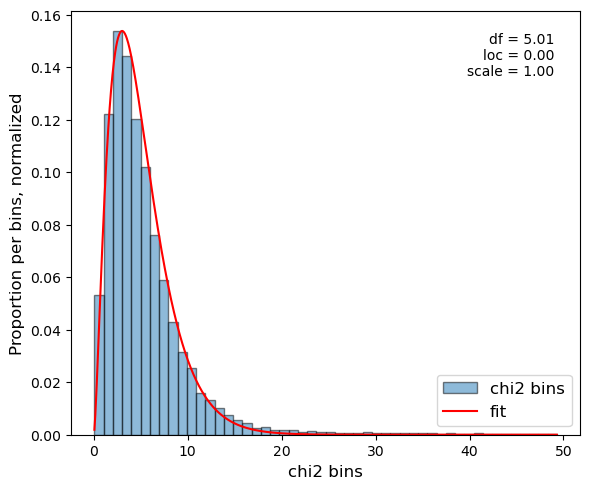

In [78]:
#--- Supposing a Chi2 dsitribution of the fitting parameter, compute the df of this distribution ---
import scipy.stats as stats

# fitting dist
chi_star = final["CHI_STAR"]
chi_star = chi_star[chi_star<50]

df, loc, scale = stats.chi2.fit(chi_star, floc=0, fscale=1.0)
x = np.linspace(min(chi_star), max(chi_star), 1000)
pdf = stats.chi2.pdf(x, df, loc, scale)

# plot
plt.figure(figsize=(6,5))
plt.hist(chi_star, bins=50, density=True, alpha=0.5, edgecolor='black', label='chi2 bins')
plt.plot(x, pdf, 'r-', label='fit')

# add fit values
plt.text(0.95, 0.95,
    f"df = {df:.2f}\nloc = {loc:.2f}\nscale = {scale:.2f}",
    transform=plt.gca().transAxes,
    verticalalignment='top',
    horizontalalignment='right',)

#
# plt.ylim(0,1)
plt.xlabel("chi2 bins", fontsize = 12)
plt.ylabel("Proportion per bins, normalized", fontsize = 12)
plt.legend(fontsize = 12)
plt.tight_layout()
plt.show()



### 4.2 Compute our own chi2

In [79]:
def compute_chi2(df, bands = ['u','g','r','i','z','y']):

    #--- init ---
    chi2_array = np.zeros(len(df))
    N_used_array = df['N_filt'].values.copy()

    # ---vectorize over bands---
    for band in bands:
        # convert to flux
        obs = 10**(-0.4*df[f'magnitude_{band}'])
        true = 10**(-0.4*df[f'magnitude_{band}_true'])
        err = np.log(10)/2.5*obs*df[f'magnitude_{band}_err_sim']

        # obs = df[f'magnitude_{band}']
        # true = df[f'magnitude_{band}_true']
        # err = df[f'magnitude_{band}_err_sim']

        #delete nan columns
        valid_mask = obs.notna() & true.notna() & err.notna() & (err != 0)

        #--- compute chi2 ---
        chi2_array += ((obs - true)**2 / err**2).where(valid_mask, 0)

        #lower N_flit
        N_used_array -= (~valid_mask).astype(int)

    # Add columns to df
    df['chi2'] = chi2_array
    df['N_filt'] = N_used_array

    return df

In [80]:
test = compute_chi2(mock_cat, bands = ['u','g','r','i','z','y'])

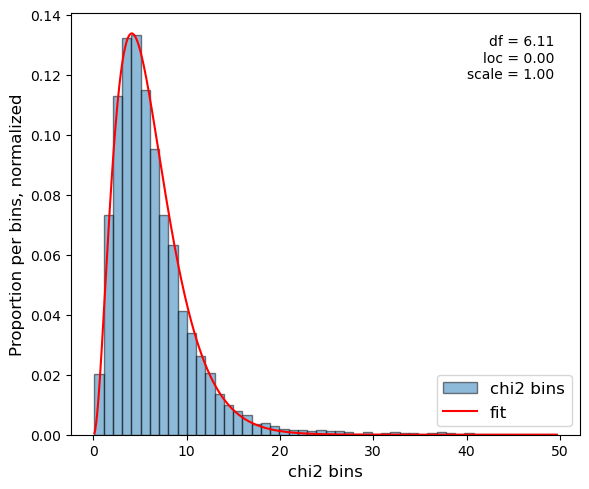

In [81]:
import scipy.stats as stats
%matplotlib inline

# fitting dist
chi_star = test[test["N_filt"]==6]["chi2"]#N_filt mask
chi_star = chi_star[chi_star<50]

df, loc, scale = stats.chi2.fit(chi_star, floc=0, fscale=1)
x = np.linspace(min(chi_star), max(chi_star), 1000)
pdf = stats.chi2.pdf(x, df, loc, scale)

# plot
plt.figure(figsize=(6,5))
plt.hist(chi_star, bins=50, density=True, alpha=0.5, edgecolor='black', label='chi2 bins')
plt.plot(x, pdf, 'r-', label='fit')

# add fit values
plt.text(0.95, 0.95,
    f"df = {df:.2f}\nloc = {loc:.2f}\nscale = {scale:.2f}",
    transform=plt.gca().transAxes,
    verticalalignment='top',
    horizontalalignment='right',)

#
# plt.ylim(0,1)
plt.xlabel("chi2 bins", fontsize = 12)
plt.ylabel("Proportion per bins, normalized", fontsize = 12)
plt.legend(fontsize = 12)
plt.tight_layout()
plt.show()

